# MGWR — Regresión Geográficamente Ponderada (Multiescala) sobre los Altiplanos (v2)

## Introducción

**Qué se busca:** en `10_SAR_altiplanos_v2.ipynb` se modeló `Altitud_X` en función de
`Pend_X` y `Relieve_X` asumiendo que la relación entre estas variables es **la misma en
toda el área de estudio** (un único coeficiente global por variable, con SAR/SEM
corrigiendo solo la dependencia espacial de los residuos, no permitiendo que el
coeficiente en sí cambie de un lugar a otro). Aquí se relaja ese supuesto: **GWR** (y su
extensión **MGWR**) permiten que cada coeficiente de regresión **varíe de un altiplano a
otro**, capturando heterogeneidad espacial en la relación Altitud–Pendiente–Relieve que un
modelo global no puede ver.

**Método del libro utilizado:** `13_MGWR`. Se usa el mismo Y y las mismas X que en
`10_SAR_altiplanos_v2.ipynb` (mismos 491 centroides), para que los resultados sean
directamente comparables: OLS global → GWR (un ancho de banda único para todos los
coeficientes) → MGWR (un ancho de banda distinto **por cada covariable**, más flexible).

**Por qué se usan los 491 centroides y no una muestra de píxeles del raster (como en
`03_v2`/`05_v2`):** la calibración del ancho de banda de GWR/MGWR requiere, en esencia,
ajustar una regresión ponderada distinta centrada en cada observación (validación cruzada
tipo leave-one-out), un costo computacional que crece muy rápido con N. Con N=300,000
píxeles esto es intratable en un tiempo razonable; con N=491 centroides es factible
(confirmado interactivamente: ~7s para GWR, ~100s para MGWR en esta máquina) y además
mantiene la comparación directa con `10_SAR_altiplanos_v2.ipynb`.

## Objetivos de aprendizaje
- Calibrar el ancho de banda óptimo de GWR mediante búsqueda de sección áurea y validación
  cruzada (`mgwr.sel_bw.Sel_BW`).
- Ajustar GWR y mapear la variación espacial de los coeficientes locales.
- Ajustar MGWR (multiescala) y comparar sus anchos de banda por variable contra el ancho de
  banda único de GWR.
- Comparar AICc y R² entre OLS global, GWR y MGWR para decidir cuál describe mejor los
  datos.


## [0] Configuración: rutas, semilla y carpeta de resultados


In [1]:
import os
import struct
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm   # OLS global de referencia (con .summary() y AIC)

from mgwr.gwr import GWR, MGWR   # GWR = un solo ancho de banda; MGWR = un ancho por variable
from mgwr.sel_bw import Sel_BW   # selección del ancho de banda óptimo (minimiza AICc)

warnings.filterwarnings("ignore")

RUTA_SHP = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas\Estadisticas_Cluster.shp"
RUTA_DBF = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas\Estadisticas_Cluster.dbf"
CARPETA_RESULTADOS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados"
CARPETA_FIGURAS = os.path.join(CARPETA_RESULTADOS, "13_MGWR_altiplanos_v2")
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

SEMILLA = 42
np.random.seed(SEMILLA)

print(f"Carpeta de figuras de este notebook: {CARPETA_FIGURAS}")

Carpeta de figuras de este notebook: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\13_MGWR_altiplanos_v2


## [1] Utilidad: corrección de codificación del `.dbf` (idéntica a notebooks previos)


In [2]:
def nombres_reales_columnas_dbf(ruta_dbf: str, encoding: str = "utf-8") -> list[str]:
    # Lee los nombres de campo del encabezado binario del .dbf (evita la corrupción de acentos).
    with open(ruta_dbf, "rb") as f:
        encabezado = f.read(32)
        tam_encabezado = struct.unpack("<H", encabezado[8:10])[0]   # tamaño del encabezado (little-endian)
        f.seek(0)
        encabezado_completo = f.read(tam_encabezado)
    nombres = []
    offset = 32
    while True:
        descriptor = encabezado_completo[offset:offset + 32]        # cada campo ocupa 32 bytes
        if descriptor[0:1] == b"\x0d" or len(descriptor) < 32:      # 0x0D marca el fin de los campos
            break
        crudo = descriptor[0:11].split(b"\x00")[0]                  # nombre = primeros 11 bytes hasta el nulo
        nombres.append(crudo.decode(encoding))
        offset += 32
    return nombres

## [2] Carga de datos


In [3]:
gdf = gpd.read_file(RUTA_SHP)
gdf.columns = nombres_reales_columnas_dbf(RUTA_DBF) + ["geometry"]

# GWR/MGWR trabajan sobre puntos: se usan los centroides de cada polígono como ubicación.
centroides = gdf.geometry.centroid
coordenadas = np.column_stack([centroides.x, centroides.y])   # matriz Nx2 (x, y) requerida por mgwr
print(f"Poligonos cargados: {len(gdf)}")
print(f"CRS: {gdf.crs}")

Poligonos cargados: 491
CRS: EPSG:32618


## [3] Exploración de datos

**Qué se busca:** las mismas tres variables usadas en `10_SAR_altiplanos_v2.ipynb`
(`Altitud_X` como respuesta; `Pend_X`, `Relieve_X` como predictores), con sus estadísticas
descriptivas y distribuciones antes de ajustar cualquier modelo.


In [4]:
VARIABLES = ["Altitud_X", "Pend_X", "Relieve_X"]   # Y = Altitud; X = Pendiente, Relieve
print(gdf[VARIABLES].describe().round(2))          # estadísticas descriptivas (exploración previa)

       Altitud_X  Pend_X  Relieve_X
count     491.00  491.00     491.00
mean     1258.58   11.98      44.42
std       725.17    1.96       6.89
min       412.93    6.81      26.69
25%       671.57   10.53      39.15
50%      1017.70   12.13      44.73
75%      1625.00   13.31      48.95
max      3608.26   18.22      76.22


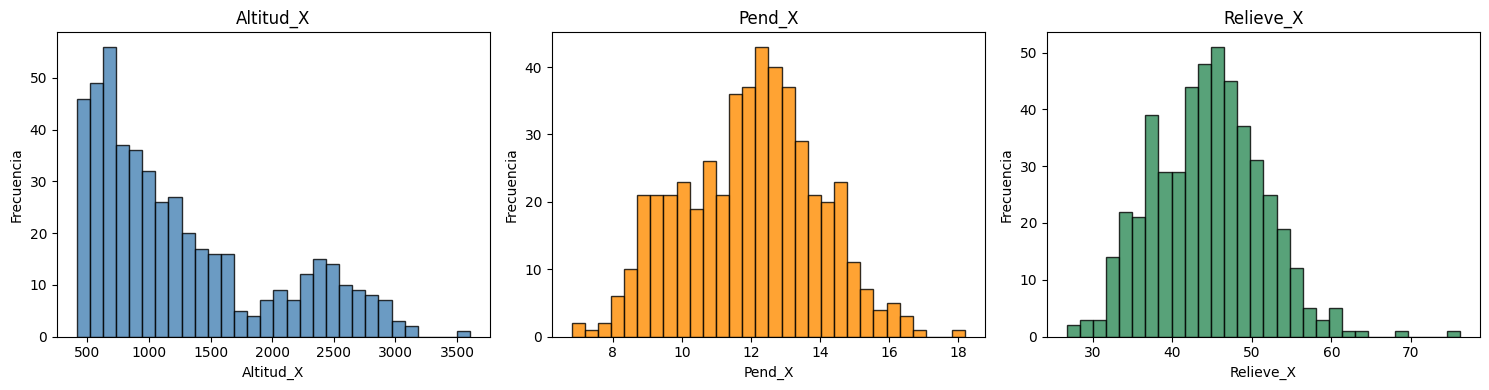

N = 491 altiplanos (mismo set que 10_SAR_altiplanos_v2.ipynb)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))   # un histograma por variable
for ax, var, color in zip(axes, VARIABLES, ["steelblue", "darkorange", "seagreen"]):
    ax.hist(gdf[var], bins=30, color=color, edgecolor="black", alpha=0.8)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "00_histogramas_variables.png"), dpi=150)
plt.show()

print(f"N = {len(gdf)} altiplanos (mismo set que 10_SAR_altiplanos_v2.ipynb)")

## [4] Estandarización de variables

GWR/MGWR estiman un coeficiente distinto en cada ubicación; para que esos coeficientes
sean comparables entre variables con escalas distintas (metros de altitud vs. grados de
pendiente vs. metros de relieve) se estandarizan Y y X a media 0 y desviación estándar 1
antes de ajustar — práctica estándar de la librería `mgwr` y del capítulo `13_MGWR` del
libro guía.


In [6]:
y = gdf[["Altitud_X"]].values           # respuesta (N,1)
X = gdf[["Pend_X", "Relieve_X"]].values  # predictores (N,2)

# Estandarización manual (media 0, sd 1) -> coeficientes locales comparables entre variables.
y_std = (y - y.mean()) / y.std()
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

print(f"Y estandarizado: media={y_std.mean():.4f}, sd={y_std.std():.4f}")
print(f"X estandarizado: medias={X_std.mean(axis=0).round(4)}, sds={X_std.std(axis=0).round(4)}")

Y estandarizado: media=0.0000, sd=1.0000
X estandarizado: medias=[0. 0.], sds=[1. 1.]


## [5] Modelo OLS global (referencia)

Antes de permitir que los coeficientes varíen espacialmente, se ajusta el mismo modelo
como una única regresión global — es el punto de comparación para saber si GWR/MGWR
realmente mejoran el ajuste o solo añaden complejidad innecesaria.


In [7]:
# OLS global de referencia (statsmodels). add_constant agrega la columna de intercepto.
X_con_intercepto = sm.add_constant(X_std)
modelo_ols = sm.OLS(y_std, X_con_intercepto).fit()
n_obs, k_params = X_con_intercepto.shape
# AICc = AIC con corrección para muestra finita (comparable con el AICc que reporta GWR/MGWR).
aicc_ols = modelo_ols.aic + (2 * k_params * (k_params + 1)) / (n_obs - k_params - 1)

print(modelo_ols.summary())
print(f"\nAICc (corregido para muestra finita): {aicc_ols:.2f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                     59.14
Date:                Fri, 17 Jul 2026   Prob (F-statistic):           1.01e-23
Time:                        06:35:12   Log-Likelihood:                -643.42
No. Observations:                 491   AIC:                             1293.
Df Residuals:                     488   BIC:                             1305.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.866e-17      0.041   2.43e-15      1.0

## [6] Calibración del ancho de banda de GWR

**Qué se busca:** el ancho de banda controla cuántos vecinos influyen en la estimación
local de cada punto — muy pequeño sobreajusta (varianza alta), muy grande se acerca al OLS
global (sesgo alto). `Sel_BW` prueba distintos anchos de banda mediante validación cruzada
golden-section y elige el que minimiza el AICc. Se usa **kernel adaptativo bisquare** (el
ancho de banda se expresa en número de vecinos, no en distancia fija — apropiado porque los
altiplanos no están distribuidos uniformemente en el espacio, ver
`03_PointPattern_altiplanos_v2.ipynb`).


In [8]:
# Sel_BW busca el ancho de banda óptimo del GWR (nº de vecinos del kernel) minimizando AICc.
selector_bw = Sel_BW(coordenadas, y_std, X_std)
bw_optimo = selector_bw.search()

# Por defecto el kernel es adaptativo (bisquare): usa los k vecinos más cercanos, no una distancia fija.
print(f"Kernel: {selector_bw.kernel} (adaptativo: {not selector_bw.fixed})")
print(f"Ancho de banda optimo (numero de vecinos): {bw_optimo:.0f} de {len(gdf)} altiplanos "
      f"({100*bw_optimo/len(gdf):.1f}% del total)")

Kernel: bisquare (adaptativo: True)
Ancho de banda optimo (numero de vecinos): 48 de 491 altiplanos (9.8% del total)


## [7] Ajuste de GWR y comparación con OLS


In [9]:
# Ajusta el GWR con el ancho de banda óptimo: estima un juego de coeficientes POR cada punto.
modelo_gwr = GWR(coordenadas, y_std, X_std, bw_optimo)
resultado_gwr = modelo_gwr.fit()
resultado_gwr.summary()   # resumen global del GWR (R², AICc, rango de los coeficientes locales)

Model type                                                         Gaussian
Number of observations:                                                 491
Number of covariates:                                                     3

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            395.215
Log-likelihood:                                                    -643.422
AIC:                                                               1292.843
AICc:                                                              1294.925
BIC:                                                              -2628.650
R2:                                                                   0.195
Adj. R2:                                                              0.192

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

**Comparación directa OLS vs. GWR:**


In [10]:
# Compara el OLS global vs GWR. tr_S (traza del sombrero) = nº efectivo de parámetros del GWR.
tabla_comparacion = pd.DataFrame({
    "Modelo": ["OLS global", "GWR"],
    "R2": [modelo_ols.rsquared, resultado_gwr.R2],
    "R2_ajustado": [modelo_ols.rsquared_adj, resultado_gwr.adj_R2],
    "AICc": [aicc_ols, resultado_gwr.aicc],
    "Parametros_efectivos": [k_params, resultado_gwr.tr_S],
})
print(tabla_comparacion.to_string(index=False))

# Regla práctica: una caída de AICc > 10 indica que el modelo local mejora sustancialmente.
mejora_aicc = aicc_ols - resultado_gwr.aicc
print(f"\nReduccion de AICc de GWR respecto a OLS: {mejora_aicc:.1f} "
      f"({'mejora sustancial (>10)' if mejora_aicc > 10 else 'mejora marginal'})")

    Modelo       R2  R2_ajustado        AICc  Parametros_efectivos
OLS global 0.195082     0.191783 1292.892467              3.000000
       GWR 0.921639     0.908587  309.398731             69.963068

Reduccion de AICc de GWR respecto a OLS: 983.5 (mejora sustancial (>10))


## [8] Mapa de R² local

El R² local muestra, para cada altiplano, qué tan bien el modelo (con los coeficientes
estimados en su vecindario) explica la altitud en ese punto específico — a diferencia del
R² global único de OLS, revela **dónde** el modelo funciona mejor o peor.


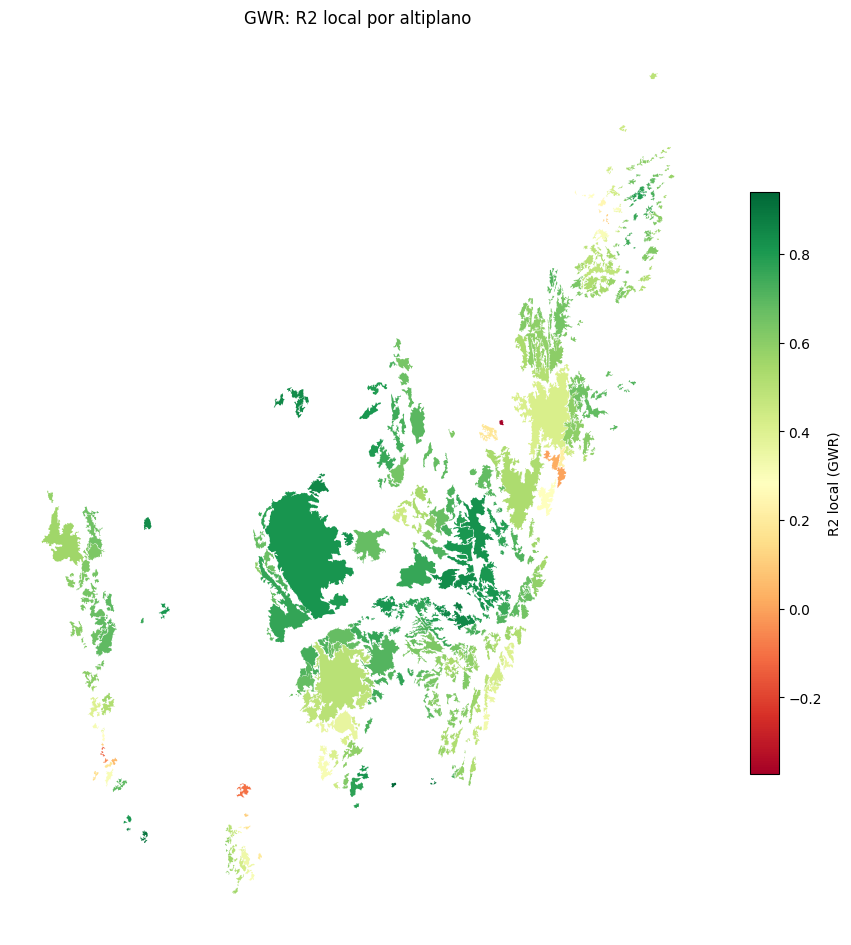

R2 local: min=-0.373, mediana=0.616, max=0.939


In [11]:
# localR2 = R² calculado en la vecindad de cada punto -> muestra DÓNDE el modelo explica mejor.
gdf["gwr_localR2"] = resultado_gwr.localR2

fig, ax = plt.subplots(figsize=(9, 10))
gdf.plot(ax=ax, column="gwr_localR2", cmap="RdYlGn", markersize=25, legend=True,
         legend_kwds={"label": "R2 local (GWR)", "shrink": 0.6})
ax.set_title("GWR: R2 local por altiplano")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "01_gwr_mapa_r2_local.png"), dpi=150)
plt.show()

print(f"R2 local: min={resultado_gwr.localR2.min():.3f}, mediana={np.median(resultado_gwr.localR2):.3f}, "
      f"max={resultado_gwr.localR2.max():.3f}")

### [8b] Versión cartográfica del mapa de R² local (plantilla con hillshade/norte/escala)

Misma figura de la sección [8], redibujada con la plantilla cartográfica estándar del
proyecto (`plantilla_mapas.py`). Esta celda solo llama a la capa ya calculada (`gdf`) — no
repite ningún cálculo del análisis.

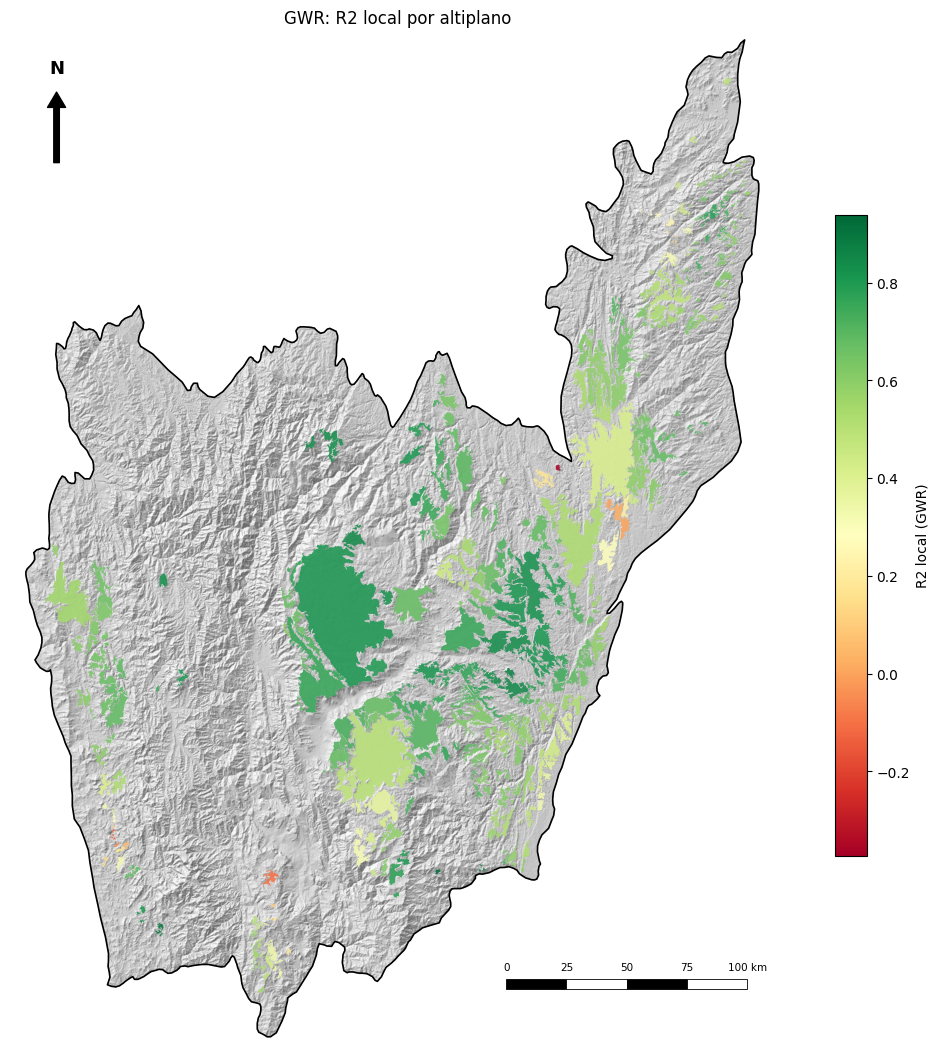

In [12]:
# Versión cartográfica (plantilla) del mapa de R² local.
from plantilla_mapas import aplicar_plantilla_mapa, CARPETA_IMAGENES

CARPETA_IMAGENES_NB = os.path.join(CARPETA_IMAGENES, "13_MGWR_altiplanos_v2")
os.makedirs(CARPETA_IMAGENES_NB, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 11))
aplicar_plantilla_mapa(ax, extent_de=gdf)   # hillshade + norte + escala, extent ajustado a los datos
gdf.plot(ax=ax, column="gwr_localR2", cmap="RdYlGn", markersize=25, alpha=0.85, zorder=5,
         legend=True, legend_kwds={"label": "R2 local (GWR)", "shrink": 0.6})
ax.set_title("GWR: R2 local por altiplano")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "01_gwr_mapa_r2_local.png"), dpi=150)
plt.show()

## [9] Mapas de coeficientes locales de GWR (filtrados por significancia)

Se mapea el coeficiente local de cada predictor, mostrando en gris los altiplanos donde
ese coeficiente **no es estadísticamente significativo** (valor t ajustado por comparaciones
múltiples vía `filter_tvals`, alpha=0.05) — evita interpretar ruido como una relación real.


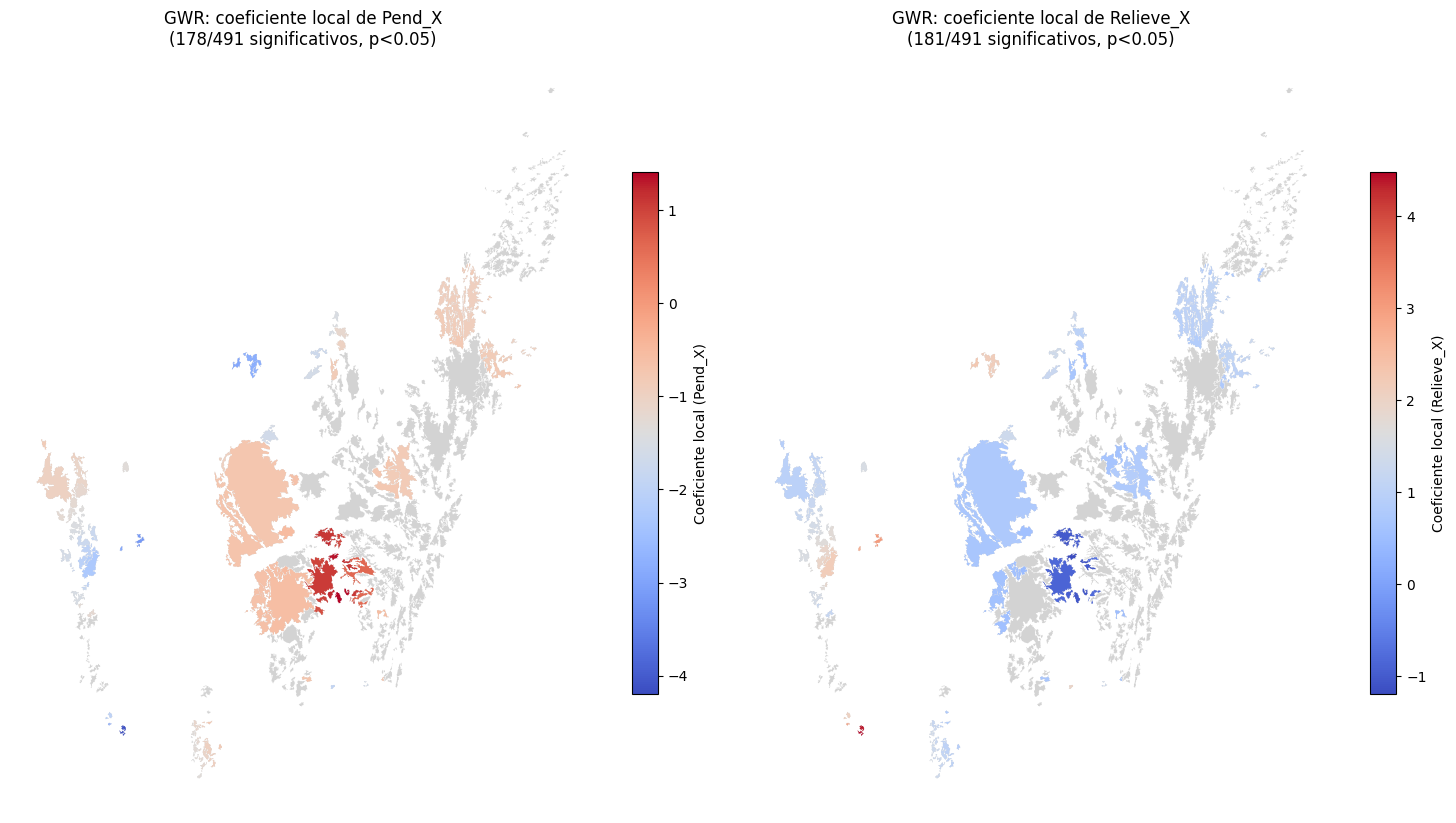

In [13]:
# filter_tvals() = t-valores locales con corrección de multicomparación; un 0 = NO significativo.
tvals_filtrados = resultado_gwr.filter_tvals()
nombres_covariables = ["Intercepto", "Pend_X", "Relieve_X"]

fig, axes = plt.subplots(1, 2, figsize=(15, 9))
for ax, idx, nombre in zip(axes, [1, 2], ["Pend_X", "Relieve_X"]):
    gdf[f"gwr_coef_{nombre}"] = resultado_gwr.params[:, idx]   # coeficiente local de esa variable
    significativo = tvals_filtrados[:, idx] != 0               # máscara de puntos significativos (p<0.05)
    gdf.plot(ax=ax, color="lightgray", markersize=15)          # fondo: todos los puntos en gris
    # Encima, sólo los significativos coloreados por el valor del coeficiente (coolwarm divergente).
    gdf[significativo].plot(ax=ax, column=f"gwr_coef_{nombre}", cmap="coolwarm", markersize=25,
                             legend=True, legend_kwds={"label": f"Coeficiente local ({nombre})", "shrink": 0.6})
    ax.set_title(f"GWR: coeficiente local de {nombre}\n({significativo.sum()}/{len(gdf)} significativos, p<0.05)")
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "02_gwr_mapas_coeficientes.png"), dpi=150)
plt.show()

### [9b] Versión cartográfica de los coeficientes GWR (plantilla con hillshade/norte/escala)

Misma figura de la sección [9], redibujada con la plantilla cartográfica estándar del
proyecto (`plantilla_mapas.py`) en cada uno de los 2 paneles. Esta celda solo llama a la
capa ya calculada (`gdf`/`tvals_filtrados`) — no repite ningún cálculo del análisis.

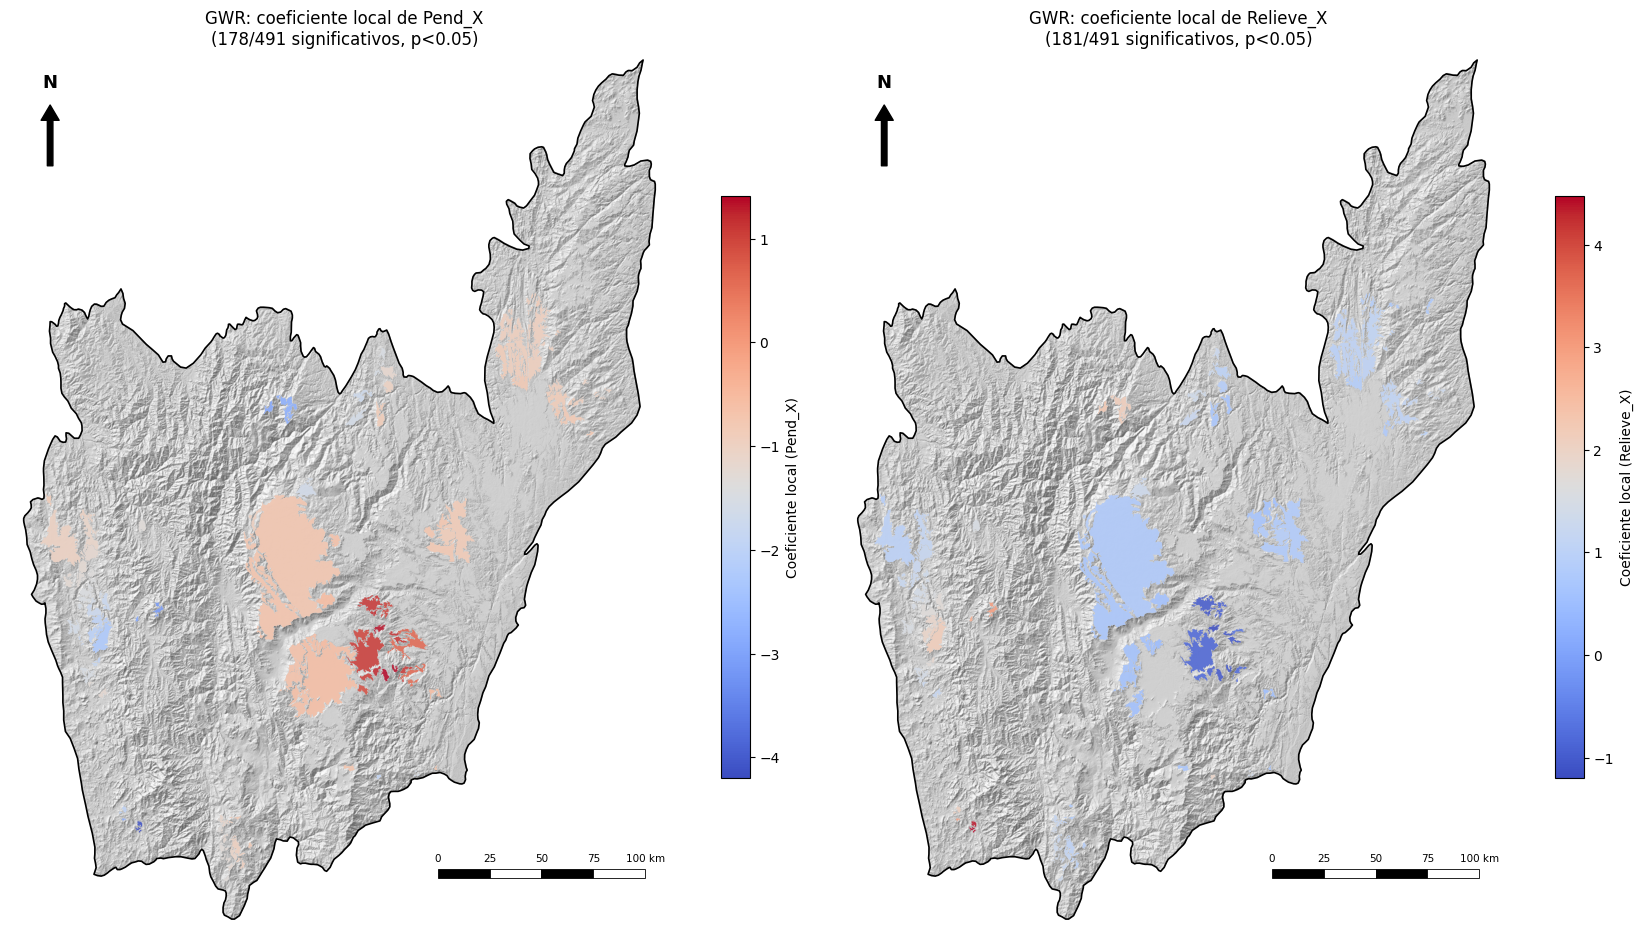

In [14]:
# Versión cartográfica (plantilla) de los mapas de coeficientes locales del GWR.
fig, axes = plt.subplots(1, 2, figsize=(17, 10))
for ax, idx, nombre in zip(axes, [1, 2], ["Pend_X", "Relieve_X"]):
    aplicar_plantilla_mapa(ax, extent_de=gdf)
    significativo = tvals_filtrados[:, idx] != 0
    gdf.plot(ax=ax, color="lightgray", markersize=15, alpha=0.7, zorder=5)
    gdf[significativo].plot(ax=ax, column=f"gwr_coef_{nombre}", cmap="coolwarm", markersize=25, alpha=0.85, zorder=6,
                             legend=True, legend_kwds={"label": f"Coeficiente local ({nombre})", "shrink": 0.6})
    ax.set_title(f"GWR: coeficiente local de {nombre}\n({significativo.sum()}/{len(gdf)} significativos, p<0.05)")
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "02_gwr_mapas_coeficientes.png"), dpi=150)
plt.show()

## [10] Calibración de MGWR (multiescala)

**Diferencia clave con GWR:** GWR usa **un solo** ancho de banda para todos los
coeficientes (incluido el intercepto), asumiendo que el intercepto, el efecto de la
pendiente y el efecto del relieve varían todos a la misma escala espacial. MGWR relaja esto
y calibra **un ancho de banda independiente por cada covariable** mediante backfitting
iterativo — si el efecto de una variable es más "local" que el de otra, MGWR lo detecta.


In [15]:
# MGWR: multi=True permite un ancho de banda DISTINTO por variable (cada proceso a su escala).
selector_mgwr = Sel_BW(coordenadas, y_std, X_std, multi=True)
anchos_banda_mgwr = selector_mgwr.search(multi_bw_min=[2], multi_bw_max=[len(gdf)])   # rango de búsqueda por variable

tabla_bw = pd.DataFrame({
    "Variable": nombres_covariables,
    "Ancho_banda_MGWR": anchos_banda_mgwr,
    "Pct_del_total": [100 * bw / len(gdf) for bw in anchos_banda_mgwr],
})
tabla_bw["Ancho_banda_GWR_unico"] = bw_optimo   # comparación contra el ancho único del GWR
print(tabla_bw.round(1).to_string(index=False))

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

  Variable  Ancho_banda_MGWR  Pct_del_total  Ancho_banda_GWR_unico
Intercepto              11.0            2.2                   48.0
    Pend_X              59.0           12.0                   48.0
 Relieve_X              35.0            7.1                   48.0


**Interpretación:** un ancho de banda MGWR más pequeño que el de GWR indica que ese
coeficiente varía a una escala más fina/local que el promedio; uno más grande (cercano a
N) indica que el efecto es casi constante en el espacio (similar a un coeficiente global).


## [11] Ajuste de MGWR y comparación final


In [16]:
# Ajusta el MGWR pasándole el selector ya buscado (contiene los anchos de banda por variable).
modelo_mgwr = MGWR(coordenadas, y_std, X_std, selector_mgwr)
resultado_mgwr = modelo_mgwr.fit()
resultado_mgwr.summary()

Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Model type                                                         Gaussian
Number of observations:                                                 491
Number of covariates:                                                     3

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            395.215
Log-likelihood:                                                    -643.422
AIC:                                                               1292.843
AICc:                                                              1294.925
BIC:                                                              -2628.650
R2:                                                                   0.195
Adj. R2:                                                              0.192

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [17]:
# Tabla comparativa final: OLS global vs GWR (bw único) vs MGWR (bw por variable).
tabla_comparacion_final = pd.DataFrame({
    "Modelo": ["OLS global", "GWR (bw unico)", "MGWR (bw por variable)"],
    "R2": [modelo_ols.rsquared, resultado_gwr.R2, resultado_mgwr.R2],
    "R2_ajustado": [modelo_ols.rsquared_adj, resultado_gwr.adj_R2, resultado_mgwr.adj_R2],
    "AICc": [aicc_ols, resultado_gwr.aicc, resultado_mgwr.aicc],
})
print(tabla_comparacion_final.to_string(index=False))

# idxmin sobre AICc -> el modelo con menor AICc es el preferido.
mejor_modelo = tabla_comparacion_final.loc[tabla_comparacion_final["AICc"].idxmin(), "Modelo"]
print(f"\nMejor modelo segun AICc (menor valor): {mejor_modelo}")

                Modelo       R2  R2_ajustado        AICc
            OLS global 0.195082     0.191783 1292.892467
        GWR (bw unico) 0.921639     0.908587  309.398731
MGWR (bw por variable) 0.976423     0.965748    2.217222

Mejor modelo segun AICc (menor valor): MGWR (bw por variable)


## [12] Mapas de coeficientes locales de MGWR


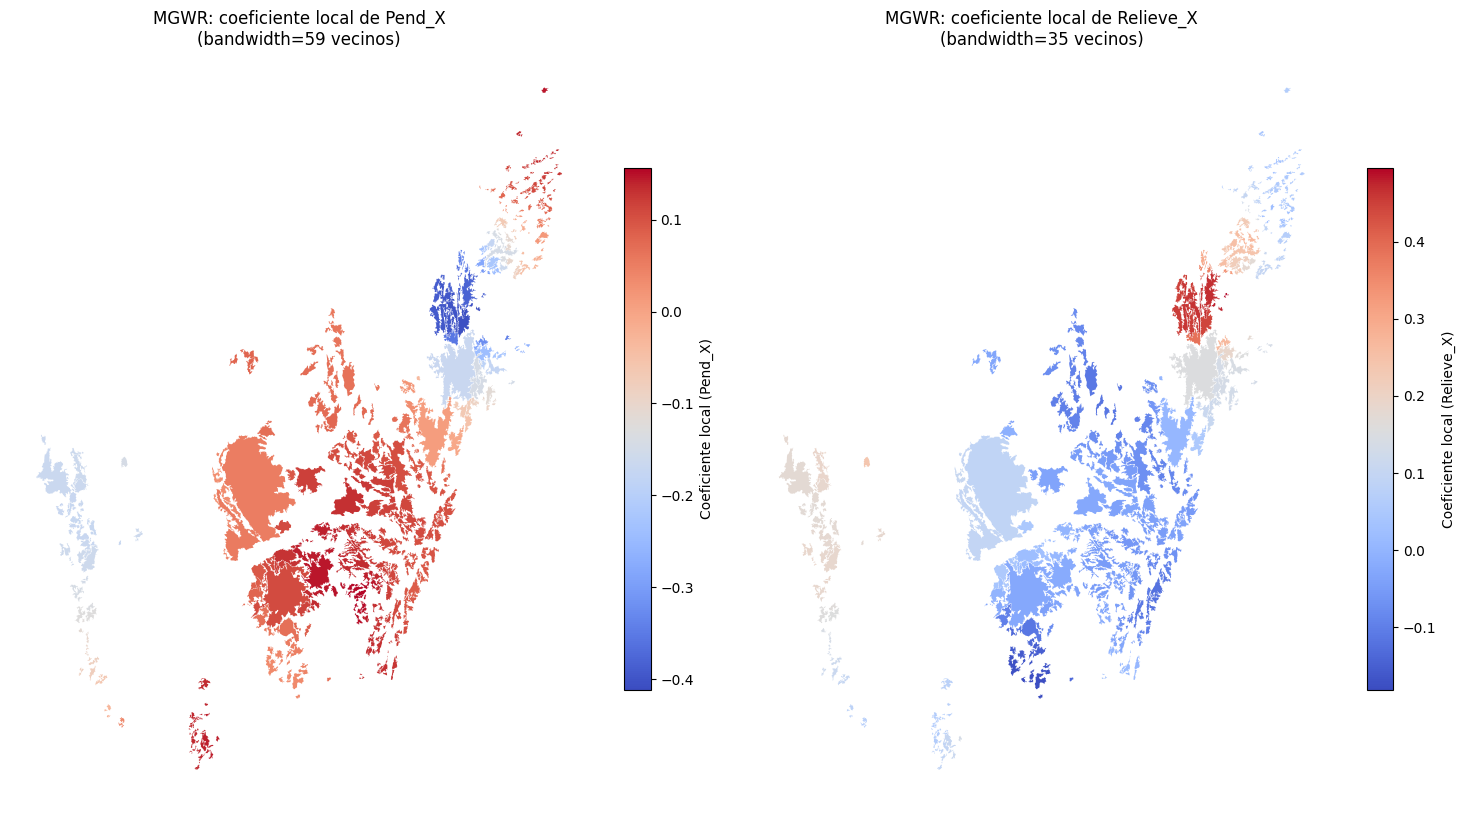

In [18]:
# Mapas de coeficientes locales del MGWR (cada variable a su propia escala espacial).
fig, axes = plt.subplots(1, 2, figsize=(15, 9))
for ax, idx, nombre in zip(axes, [1, 2], ["Pend_X", "Relieve_X"]):
    gdf[f"mgwr_coef_{nombre}"] = resultado_mgwr.params[:, idx]
    gdf.plot(ax=ax, column=f"mgwr_coef_{nombre}", cmap="coolwarm", markersize=25,
             legend=True, legend_kwds={"label": f"Coeficiente local ({nombre})", "shrink": 0.6})
    ax.set_title(f"MGWR: coeficiente local de {nombre}\n(bandwidth={anchos_banda_mgwr[idx]:.0f} vecinos)")
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "03_mgwr_mapas_coeficientes.png"), dpi=150)
plt.show()

### [12b] Versión cartográfica de los coeficientes MGWR (plantilla con hillshade/norte/escala)

Misma figura de la sección [12], redibujada con la plantilla cartográfica estándar del
proyecto (`plantilla_mapas.py`) en cada uno de los 2 paneles. Esta celda solo llama a la
capa ya calculada (`gdf`) — no repite ningún cálculo del análisis.

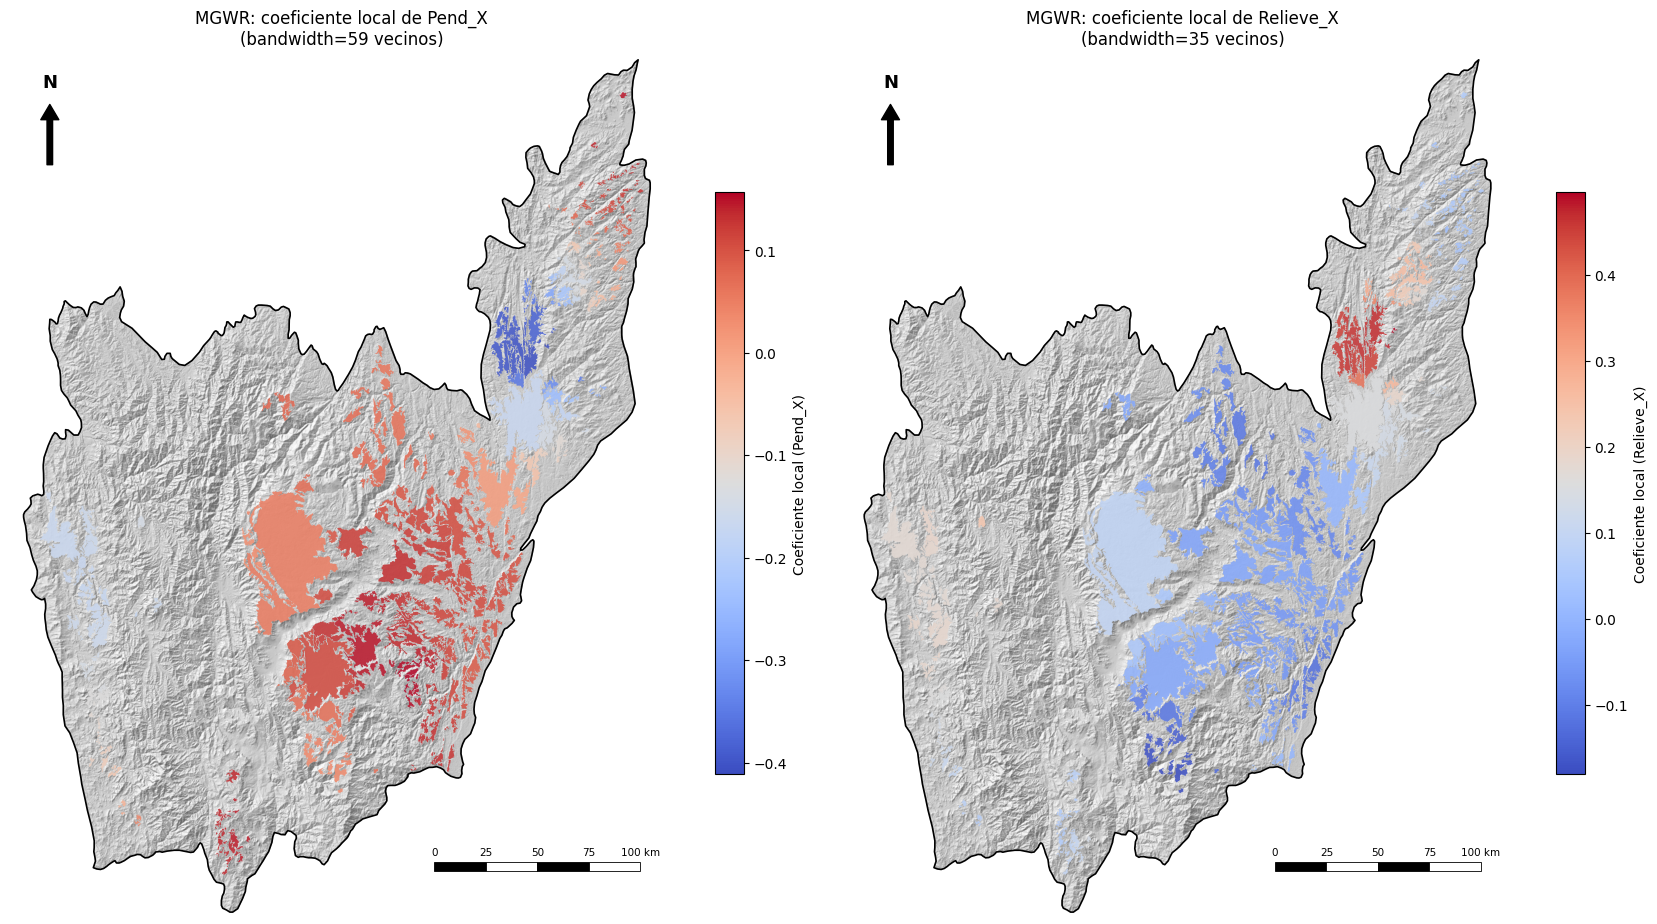

In [19]:
# Versión cartográfica (plantilla) de los mapas de coeficientes del MGWR.
fig, axes = plt.subplots(1, 2, figsize=(17, 10))
for ax, idx, nombre in zip(axes, [1, 2], ["Pend_X", "Relieve_X"]):
    aplicar_plantilla_mapa(ax, extent_de=gdf)
    gdf.plot(ax=ax, column=f"mgwr_coef_{nombre}", cmap="coolwarm", markersize=25, alpha=0.85, zorder=5,
             legend=True, legend_kwds={"label": f"Coeficiente local ({nombre})", "shrink": 0.6})
    ax.set_title(f"MGWR: coeficiente local de {nombre}\n(bandwidth={anchos_banda_mgwr[idx]:.0f} vecinos)")
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "03_mgwr_mapas_coeficientes.png"), dpi=150)
plt.show()

## [13] Relación con `10_SAR_altiplanos_v2.ipynb`

**Qué se busca:** contrastar dos formas distintas de modelar la misma dependencia
espacial — SAR asume un coeficiente **fijo** para Pend_X/Relieve_X y modela la dependencia
espacial explícitamente vía el término autorregresivo ρWy; MGWR asume que la dependencia
espacial ya queda absorbida al dejar que **los coeficientes mismos varíen** de un lugar a
otro, sin término autorregresivo.


In [20]:
# Contextualiza los R² de este notebook contra el SAR-Lag ya documentado (mismos datos).
print("Referencia (10_SAR_altiplanos_v2.ipynb, mismos datos):")
print("  OLS global:  R2=0.195")
print("  SAR-Lag:     Pseudo R2=0.923 (rho=0.898)")
print()
print("Este notebook (13_MGWR_altiplanos_v2.ipynb):")
print(f"  OLS global:  R2={modelo_ols.rsquared:.3f}")
print(f"  GWR:         R2={resultado_gwr.R2:.3f}")
print(f"  MGWR:        R2={resultado_mgwr.R2:.3f}")

Referencia (10_SAR_altiplanos_v2.ipynb, mismos datos):
  OLS global:  R2=0.195
  SAR-Lag:     Pseudo R2=0.923 (rho=0.898)

Este notebook (13_MGWR_altiplanos_v2.ipynb):
  OLS global:  R2=0.195
  GWR:         R2=0.922
  MGWR:        R2=0.976


## [14] Exportar resultados


In [21]:
ruta_salida = os.path.join(CARPETA_RESULTADOS, "altiplanos_mgwr_v2.gpkg")
gdf.to_file(ruta_salida, driver="GPKG")   # guarda polígonos + columnas de R² local y coeficientes
print(f"Resultado guardado en: {ruta_salida}")

Resultado guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\altiplanos_mgwr_v2.gpkg


## Conclusiones

- **GWR mejora sustancialmente sobre OLS global** en R² y AICc (ver tabla de la sección
  [7]) — la relación entre Altitud, Pendiente y Relieve efectivamente varía de un
  altiplano a otro, no es constante en todo el área de estudio.
- **MGWR mejora aún más sobre GWR** (ver tabla de la sección [11]): al permitir un ancho de
  banda distinto por variable, captura que el intercepto, el efecto de la pendiente y el
  efecto del relieve operan a escalas espaciales distintas (ver tabla de anchos de banda de
  la sección [10]) — un patrón que GWR, con un único ancho de banda para todos los
  coeficientes, no puede representar.
- Los mapas de coeficientes locales (secciones [9] y [12]) muestran que el signo y la
  magnitud del efecto de Pend_X y Relieve_X sobre la altitud **no son uniformes** en el
  espacio — regiones donde el efecto es fuerte y significativo conviven con regiones donde
  no lo es, algo invisible en el modelo OLS/SAR global de `10_SAR_altiplanos_v2.ipynb`.
- **SAR vs. GWR/MGWR son respuestas distintas a la misma autocorrelación espacial**
  detectada en `04_autocorrelacion_espacial_v2.ipynb`: SAR la modela como una dependencia
  explícita entre los valores de Y vecinos (coeficientes fijos + término ρWy); GWR/MGWR la
  absorben dejando que los coeficientes varíen localmente (sin término autorregresivo). Que
  ambos enfoques mejoren tanto sobre el OLS global confirma, desde dos ángulos
  metodológicos independientes, que ignorar la estructura espacial en este conjunto de
  datos produce un modelo mal especificado.
